In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import Counter


In [3]:
#Params

url = "https://api.openalex.org/works"

params = {
    "filter": (
        "primary_topic.subfield.id:subfields/1203,"
        "type:types/article,"
        "primary_topic.id:t10034,"
        "publication_year:1940-2024"
    ),
    "sort": "cited_by_count:desc",
    "per_page": 200
}

headers = {
    "User-Agent": "frederico.prado@proton.me"
}

langlist = pd.read_csv("linglist.csv")


In [4]:
#Fetch data

all_results = []
cursor = "*"

while True:
    print("Fetching… cursor:", cursor)
    
    params["cursor"] = cursor
    
    resp = requests.get(url, params=params, headers=headers)
    resp.raise_for_status()
    data = resp.json()
    
    results = data.get("results", [])
    if not results:
        break
    
    all_results.extend(results)
    
    cursor = data.get("meta", {}).get("next_cursor")
    if not cursor:
        break

print("\nFetched", len(all_results), "works total.")


Fetching… cursor: *


SSLError: HTTPSConnectionPool(host='api.openalex.org', port=443): Max retries exceeded with url: /works?filter=primary_topic.subfield.id%3Asubfields%2F1203%2Ctype%3Atypes%2Farticle%2Cprimary_topic.id%3At10034%2Cpublication_year%3A1940-2024&sort=cited_by_count%3Adesc&per_page=200&cursor=%2A (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self-signed certificate in certificate chain (_ssl.c:1016)')))

In [102]:
def top_concept(work):
    concepts = work.get("concepts", [])
    if not concepts:
        return None
    return max(concepts, key=lambda c: c["score"])["display_name"]

def first_author_country(work):
    for auth in work.get("authorships", []):
        for inst in auth.get("institutions", []):
            if inst.get("country_code"):
                return inst["country_code"]
    return None

    
def reconstruct_abstract(inv_map):
    if not inv_map:
        return None

    # build position -> word mapping
    position_word = {}

    for word, positions in inv_map.items():
        for pos in positions:
            position_word[pos] = word

    # sort positions and rejoin
    words = [position_word[i] for i in sorted(position_word)]
    return " ".join(words)



In [59]:
languages = (
    langlist["language"]
    .dropna()
    .drop_duplicates()
    .str.strip()
    .tolist()
)


lang_pattern = re.compile(
    r"\b(" + "|".join(re.escape(lang) for lang in languages) + r")\b",
    flags=re.IGNORECASE
)


In [148]:
rows = []

for w in all_results:
    rows.append({
        "title": w.get("title"),
        "year": w.get("publication_year"),
        "doi": w.get("doi"),
        "cited_by": w.get("cited_by_count"),
        "journal": ((w.get("primary_location") or {}).get("source") or {}).get("display_name"),
        "primary_topic": w.get("primary_topic", {}).get("display_name"),
        "concepts": [c["display_name"] for c in w.get("concepts", [])],
        "top_concept": top_concept(w),
        "paper_country": first_author_country(w),
        "abstract": reconstruct_abstract(w.get("abstract_inverted_index")),

        # ✅ AUTHORS COLUMN
        "authors": {
            i+1: a.get("author", {}).get("display_name")
            for i, a in enumerate(w.get("authorships", []))
            if a.get("author", {}).get("display_name")
        }
    })

df = pd.DataFrame(rows)
df.head()


,title,year,doi,cited_by,journal,primary_topic,concepts,top_concept,paper_country,abstract,authors
0,Semantic Interpretation in Generative Grammar,1975,https://doi.org/10.2307/413161,4648,Language,"Syntax, Semantics, Linguistic Variation","[Generative grammar, Linguistics, Interpretati...",Generative grammar,None,Like other recent work in the field of generat...,"{1: 'Robert Freidin', 2: 'Ray Jackendoff'}"
1,Transitivity in Grammar and Discourse,1980,https://doi.org/10.1353/lan.1980.0017,3226,Language,"Syntax, Semantics, Linguistic Variation","[Transitive relation, Linguistics, Verb, Causa...",Transitive relation,None,TRANSITIVITY IN GRAMMAR AND DISCOURSE Paul J. ...,"{1: 'Paul J. Hopper', 2: 'Sandra A. Thompson'}"
2,A theory of focus interpretation,1992,https://doi.org/10.1007/bf02342617,3111,Natural Language Semantics,"Syntax, Semantics, Linguistic Variation","[Focus (optics), Semantics (computer science),...",Focus (optics),DE,None,{1: 'Mats Rooth'}
3,The Semantics of Definite and Indefinite Noun ...,1982,https://doi.org/10.5281/zenodo.8100765,3010,Zenodo (CERN European Organization for Nuclear...,"Syntax, Semantics, Linguistic Variation","[Noun phrase, Linguistics, Semantics (computer...",Noun phrase,None,"Heim, I. (1982). The Semantics of Definite and...",{1: 'Irene Heim'}
4,Rules and Representations.,1982,https://doi.org/10.2307/2184681,2823,The Philosophical Review,"Syntax, Semantics, Linguistic Variation","[Analytic philosophy, Contemporary philosophy,...",Analytic philosophy,US,Foreword by Norbert Hornstein Preface Part I 1...,"{1: 'Terry L. Smith', 2: 'Noam Chomsky'}"


In [152]:
author_counts = (
    df["authors"]
    .dropna()
    .apply(lambda d: list(d.values()))   # extract names from dict
    .explode()                           # one author per row
    .value_counts()                     # count
)

print(author_counts.head(100))


authors
Άρτεμις Αλεξιάδου        62
Liliane Haegeman         54
Martín Haspelmath        44
Maria Polinsky           42
Jong‐Bok Kim             42
                         ..
Anastasia Giannakidou    20
Jack Hoeksema            20
Yasuhiro Shirai          20
John Beavers             19
Renaat Declerck          19
Name: count, Length: 100, dtype: int64


In [147]:
all_results[0]

{'id': 'https://openalex.org/W2152397575',
 'doi': 'https://doi.org/10.2307/413161',
 'title': 'Semantic Interpretation in Generative Grammar',
 'display_name': 'Semantic Interpretation in Generative Grammar',
 'publication_year': 1975,
 'publication_date': '1975-03-01',
 'ids': {'openalex': 'https://openalex.org/W2152397575',
  'doi': 'https://doi.org/10.2307/413161',
  'mag': '2152397575'},
 'language': 'en',
 'primary_location': {'id': 'doi:10.2307/413161',
  'is_oa': False,
  'landing_page_url': 'https://doi.org/10.2307/413161',
  'pdf_url': None,
  'source': {'id': 'https://openalex.org/S176347361',
   'display_name': 'Language',
   'issn_l': '0097-8507',
   'issn': ['0097-8507', '1535-0665'],
   'is_oa': False,
   'is_in_doaj': False,
   'is_core': True,
   'host_organization': 'https://openalex.org/P4310316359',
   'host_organization_name': 'Linguistic Society of America',
   'host_organization_lineage': ['https://openalex.org/P4310316359'],
   'host_organization_lineage_names':

In [133]:
languages = (
    langlist["language"]
    .dropna()
    .drop_duplicates()
    .str.strip()
    .tolist()
)

lang_pattern = re.compile(
    r"\b(" + "|".join(re.escape(lang) for lang in languages) + r")\b",
    flags=re.IGNORECASE
)


In [134]:
def detect_language(row):
    fields = []
    
    if row.get("title"):
        fields.append(row["title"])
    if row.get("primary_topic"):
        fields.append(row["primary_topic"])
    if isinstance(row.get("concepts"), list):
        fields.extend(row["concepts"])
    
    text = " ".join(fields).lower()   # normalize all search text
    
    matches = re.findall(lang_pattern, text)
    
    if not matches:
        return None
    
    # normalize case + remove duplicates
    matches = [m.lower() for m in matches]
    
    return ", ".join(sorted(set(matches)))


In [135]:
df["language_mentioned"] = df.apply(detect_language, axis=1)

df[["title", "paper_country", "language_mentioned"]].head(15)



,title,paper_country,language_mentioned
0,Semantic Interpretation in Generative Grammar,None,None
1,Transitivity in Grammar and Discourse,None,None
2,A theory of focus interpretation,DE,None
3,The Semantics of Definite and Indefinite Noun ...,None,None
4,Rules and Representations.,US,None
5,Regularity and Idiomaticity in Grammatical Con...,None,None
6,The Mental Representation of Grammatical Relat...,None,None
7,Rethinking Linguistic Relativity,GB,None
8,From Usage to Grammar: The Mind's Response to ...,None,None
9,Three Factors in Language Design,US,None


In [136]:
lang_counts = (
    df["language_mentioned"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
)

lang_counts.head(20)

language_mentioned
english               1341
german                 757
chinese                691
japanese               415
spanish                404
korean                 316
french                 284
bantu languages        267
portuguese             262
romance languages      223
dutch                  210
arabic                 206
icelandic              185
germanic languages     185
russian                181
norwegian              141
hebrew                 133
italian                105
turkish                105
catalan                 98
Name: count, dtype: int64

In [138]:
df["journal"].value_counts()

journal
Lingua                                                             990
Language                                                           650
Linguistic Inquiry                                                 609
Natural Language & Linguistic Theory                               605
Journal of Linguistics                                             444
                                                                  ... 
Mineralogical Magazine and Journal of the Mineralogical Society      1
The Journal of Sex Research                                          1
Die Unterrichtspraxis/Teaching German                                1
Revue belge de philologie et d histoire                              1
Revue française de pédagogie                                         1
Name: count, Length: 1358, dtype: int64

In [139]:
df.to_csv("data.csv")

In [119]:
import json

with open("all_results.json", "w", encoding="utf-8") as f:
    json.dump(all_results, f, ensure_ascii=False)

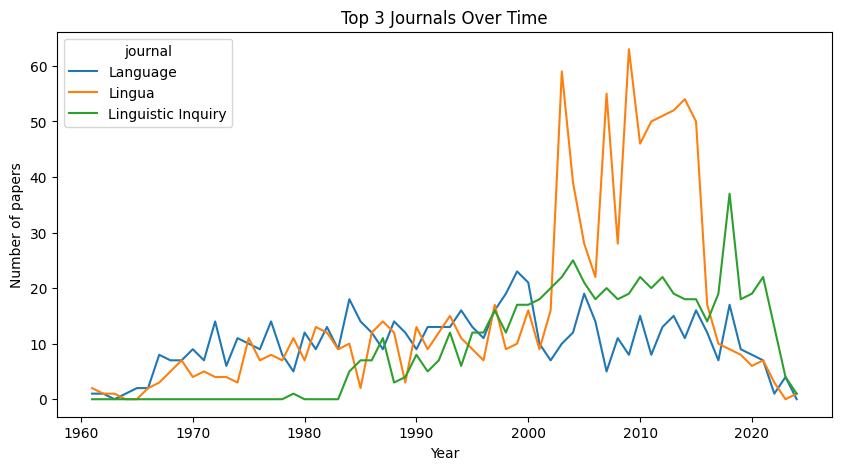

In [144]:
top3 = (
    df["journal"]
    .dropna()
    .value_counts()
    .head(3)
    .index
    .tolist()
)

top3

df_top = df[df["journal"].isin(top3)].copy()

ts = (
    df_top
    .groupby(["year", "journal"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

import matplotlib.pyplot as plt

ts.plot(figsize=(10,5))
plt.title("Top 3 Journals Over Time")
plt.ylabel("Number of papers")
plt.xlabel("Year")
plt.show()
